A business records its employees' yearly salaries. We want to answer:

1. What are the highest and lowest salaries, and how many years of experience do those employees have?
2. Does salary generally increase as years of experience increase?
3. What's the typical salary for employees with 1-5 years, 5-10 years, or 10+ years of experience?
4. What is the average number of years of experience do the employees have?

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. What are the highest and lowest salaries, and how many years of experience do those employees have? Hard

In [ ]:
# Load the dataset
df = pd.read_csv('/content/Salary_dataset.csv')

# Rename 'Unnamed: 0' column to 'Employee ID'
df = df.rename(columns={'Unnamed: 0': 'Employee ID'})

# Create 'Experience_Group' column
def get_experience_group(years):
    if years <= 5:
        return '1-5 years'
    elif 5 < years <= 10:
        return '5-10 years'
    else:
        return '10+ years'

df['Experience_Group'] = df['YearsExperience'].apply(get_experience_group)

# Find the row with the highest salary
highest_salary_row = df.loc[df["Salary"].idxmax()]

# Find the row with the lowest salary
lowest_salary_row = df.loc[df['Salary'].idxmin()]

# Define the columns the user wants to see
selected_display_columns = ['Employee ID', 'YearsExperience', "Salary", 'Experience_Group']

# Print label for the highest salary employee detail
print("Employee with the Highest Salary: ")

# Create a temporary DataFrame for display for the highest salary row and format 'Employee ID
display_highest_salary = highest_salary_row[selected_display_columns].to_frame().T
display_highest_salary['Employee ID'] = display_highest_salary['Employee ID'].apply(lambda x: f'{int(x):03d}')

# Display selected columns for the employee with the highest salary
display(display_highest_salary)

# Print the highest salary and its associated years of experience
print(f"Highest Salary: ${highest_salary_row['Salary']:.2f} with {highest_salary_row['YearsExperience']} years of experience")

# Print a label for the lowest salary employee details, with a newline for spacing
print("\nEmployee with Lowest Salary: ")

# Create a temporary DataFrame for display for the lowest salary row and format 'Employee ID'
display_lowest_salary = lowest_salary_row[selected_display_columns].to_frame().T
display_lowest_salary['Employee ID'] = display_lowest_salary['Employee ID'].apply(lambda x: f'{int(x):03d}')

# Display selected columns for the employee with the lowest salary
display(display_lowest_salary)

# Print the lowest salary and its associated years of experience
print(f"Lowest Salary: ${lowest_salary_row['Salary']:.2f} with {lowest_salary_row['YearsExperience']} years of experience")

Employee with Highest Salary: 


,Employee ID,YearsExperience,Salary,Experience_Group
28,028,10.4,122392.0,10+ years


Highest Salary: $122392.00 with 10.4 years of experience

Employee with Lowest Salary: 


,Employee ID,YearsExperience,Salary,Experience_Group
2,002,1.6,37732.0,1-5 years


Lowest Salary: $37732.00 with 1.6 years of experience


How does it work:
This code finds the employees with the highest and lowest salaries by locating their positions in the dataset. It then retrieves their information and displays both a brief summary and a detailed table, making it easy to compare their salary details.

What does the answer mean:
The answer to question 1 clearly highlights the range of salaries and experience levels within your employee data. It shows us the highest-paid employee, who has significant experience, and the lowest-paid employee, with less experience.

# 2. Does salary generally increase as years of experience increase? Hard


Pearson correlation between YearsExperience and Salary: 0.98


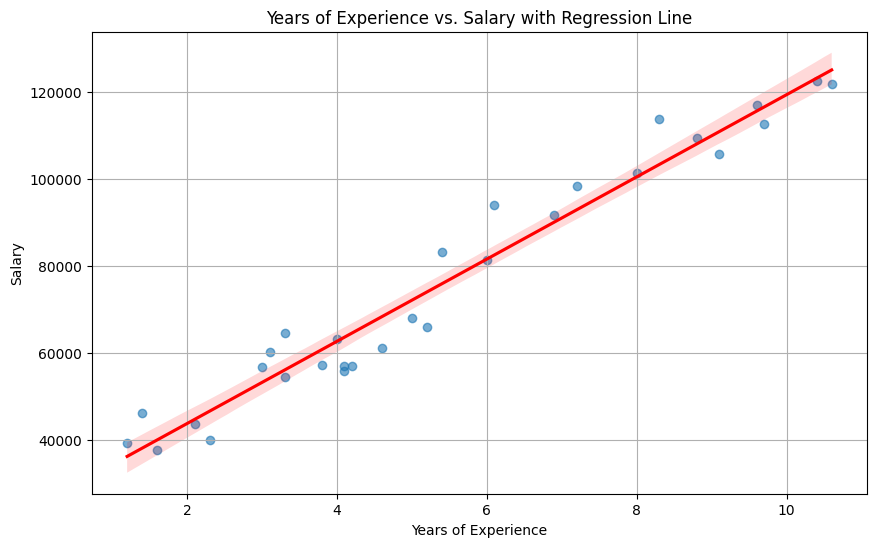


Employee Experience and Salary Trend (sorted by Salary):


,Employee ID,YearsExperience,Salary
0,002,1.6,37732.0
1,000,1.2,39344.0
2,004,2.3,39892.0
3,003,2.1,43526.0
4,001,1.4,46206.0
5,007,3.3,54446.0
6,011,4.1,55795.0
7,005,3.0,56643.0
8,012,4.1,56958.0
9,013,4.2,57082.0


In [ ]:
# Calculate the Pearson correlation coefficient between 'YearsExperience' and 'Salary'
correlation = df['YearsExperience'].corr(df['Salary'])
print(f"Pearson correlation between YearsExperience and Salary: {correlation:.2f}")

# Create a scatter plot of YearsExperience vs Salary with a regression line
plt.figure(figsize=(10, 6))
sns.regplot(x='YearsExperience', y='Salary', data=df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Years of Experience vs. Salary with Regression Line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.grid(True)
plt.show()

print("\nEmployee Experience and Salary Trend (sorted by Salary):")
# Apply formatting to 'Employee ID' before displaying
df_display = df[['Employee ID', 'YearsExperience', 'Salary']].sort_values(by='Salary').reset_index(drop=True)
df_display['Employee ID'] = df_display['Employee ID'].apply(lambda x: f'{int(x):03d}')
display(df_display)


How does it work:
The code calculates a 'correlation coefficient' to measure the strength of the relationship between salary and experience. It then creates a scatter plot with a regression line to visually show if salary generally increases with more experience and how consistent that trend is. Also, a table to show it as well is provided.

What does the answer mean:
This means that employees with more experience generally earn higher salaries. The graph and table clearly show salary increasing steadily with each extra year of experience, indicating a strong link between experience and pay.

# 3. What's the typical salary for employees with 1-5 years, 5-10 years, or 10+ years of experience? Medium


Typical Salary for different Experience Groups:


,Experience_Group,Salary
0,1-5 years,52916.133333
1,5-10 years,95547.153846
2,10+ years,122132.500000


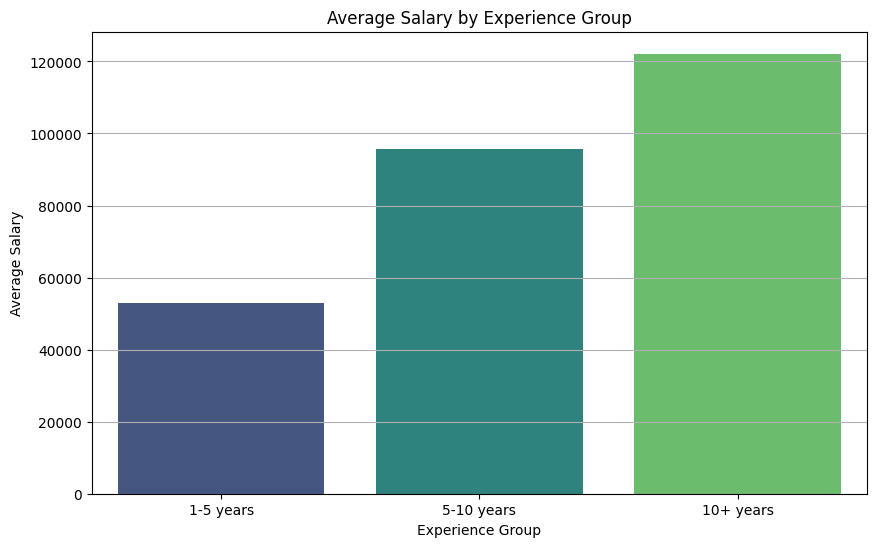

In [ ]:
# Define experience bins and labels
bins = [0, 5, 10, df['YearsExperience'].max() + 1]
labels = ['1-5 years', '5-10 years', '10+ years']

# Create a new column 'Experience_Group' based on the bins
df['Experience_Group'] = pd.cut(df['YearsExperience'], bins=bins, labels=labels, right=False)

# Calculate the mean salary for each experience group
typical_salaries = df.groupby('Experience_Group', observed=False)['Salary'].mean().reset_index()

print("Typical Salary for different Experience Groups:")
display(typical_salaries)

# Create a bar plot to visualize typical salaries by experience group
plt.figure(figsize=(10, 6))
sns.barplot(x='Experience_Group', y='Salary', data=typical_salaries, palette='viridis', hue='Experience_Group', legend=False)
plt.title('Average Salary by Experience Group')
plt.xlabel('Experience Group')
plt.ylabel('Average Salary')
plt.grid(axis='y')
plt.show()

How does it work:
The analysis shows a clear upward trend in average salary as experience increases. Employees in the "1-5 years" group have the lowest average salary, while those with "10+ years" of experience earn significantly more. This demonstrates how salary progresses with career length in this dataset.

What does the answer mean:
Shows that employees earn more as their experience grows. Those with 1-5 years of experience have the lowest average salary, and salaries significantly increase for those with 10+ years. This highlights how salary progresses with career length in this dataset.

# 4. What is the average number of years of experience do the employees have? Easy

In [ ]:
# Calculate the average of the 'YearsExperience' column
average_experience = df['YearsExperience'].mean()

# Print the calculated average years of experience in a formatted string
print(f"The average number of years of experience for employees is: {average_experience:.2f} years")

# Print a label for the table display
print("\nAverage Years of Experience:")

# Create a DataFrame to display the average experience
df_q4_answer = pd.DataFrame({'Average Years of Experience': [average_experience]})

# Display the DataFrame 'df_q4_answer' which contains the average experience in a table format
display(df_q4_answer)

The average number of years of experience for employees is: 5.41 years

Average Years of Experience:


,Average Years of Experience
0,5.413333


How does it work:
This code calculates the average years of experience by summing up all employees' years of experience and dividing by the total number of employees. It uses a built-in function to efficiently perform this calculation.

What does the answer mean:
The answer shows that the average employee in this dataset has approximately   5.41 years of experience. This number gives a quick understanding of the typical experience level across the entire group of employees.